# 03 - Model Training (Classification)

**Objective:** Build and evaluate classification models to predict English Premier League match outcomes.

- Task: Classification
- Models: Logistic Regression (Baseline), Random Forest, XGBoost
- Target Variable: `FTR` (Home Win = 1)
- Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
print(os.getcwd())
print(os.listdir())
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

from xgboost import XGBClassifier


e:\Documents\EPL-HomeWin-Prediction\notebooks
['01_KhamPhaDuLieu.ipynb', '02_LamSachDuLieu.ipynb', '03_HuanLuyenModel.ipynb', 'confusion_matrices.png', 'feature_importance.png', 'roc_curve_comparison.png']


## 2. Load Cleaned Data

In [3]:
df = pd.read_csv('../data/cleaned_data.csv')

# Parse Date and sort chronologically to ensure temporal order
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Shape: (6840, 42)
Date range: 2000-08-19 00:00:00 to 2018-05-13 00:00:00


,Date,FTR,HTP,ATP,HTFormPts,ATFormPts,HTWinStreak3,HTWinStreak5,HTLossStreak3,HTLossStreak5,...,AM1_M,AM1_W,AM2_D,AM2_L,AM2_M,AM2_W,AM3_D,AM3_L,AM3_M,AM3_W
0,2000-08-19,1,0.0,0.0,0,0,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False
1,2000-08-19,1,0.0,0.0,0,0,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False
2,2000-08-19,0,0.0,0.0,0,0,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False
3,2000-08-19,0,0.0,0.0,0,0,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False
4,2000-08-19,1,0.0,0.0,0,0,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False


## 3. Feature Selection

The selected features represent:

- Team strength (`DiffPts`, `HTGD`)
- Recent form (`DiffFormPts`)
- Match momentum (`Win/Loss Streak`)
- Recent results (`HMx`, `AMx`)

Variables directly related to final results (e.g., goals scored) were excluded to avoid data leakage.

In [4]:
# Target variable
target = 'FTR'

# Feature list for model training
# Excluded: FTHG, FTAG (direct match results -> data leakage)
# Excluded: HTGS, ATGS, HTGC, ATGC (already synthesized into HTGD, ATGD)
FEATURES = [
    'DiffPts', 'DiffFormPts', 'HTGD', 'ATGD',
    'HTWinStreak3', 'HTWinStreak5',
    'HTLossStreak3', 'HTLossStreak5',
    'ATWinStreak3', 'ATWinStreak5',
    'ATLossStreak3', 'ATLossStreak5',
    'HM1_D', 'HM1_L', 'HM1_W',
    'HM2_D', 'HM2_L', 'HM2_W',
    'HM3_D', 'HM3_L', 'HM3_W',
    'AM1_D', 'AM1_L', 'AM1_W',
    'AM2_D', 'AM2_L', 'AM2_W',
    'AM3_D', 'AM3_L', 'AM3_W'
]

print(f"Number of features: {len(FEATURES)}")
print(f"Features: {FEATURES}")


Number of features: 30
Features: ['DiffPts', 'DiffFormPts', 'HTGD', 'ATGD', 'HTWinStreak3', 'HTWinStreak5', 'HTLossStreak3', 'HTLossStreak5', 'ATWinStreak3', 'ATWinStreak5', 'ATLossStreak3', 'ATLossStreak5', 'HM1_D', 'HM1_L', 'HM1_W', 'HM2_D', 'HM2_L', 'HM2_W', 'HM3_D', 'HM3_L', 'HM3_W', 'AM1_D', 'AM1_L', 'AM1_W', 'AM2_D', 'AM2_L', 'AM2_W', 'AM3_D', 'AM3_L', 'AM3_W']


**Note:** Variables `FTHG`, `FTAG`, `HTGS`, `ATGS`, `HTGC`, `ATGC`, `HTP`,`ATP` are not included because:
- `FTHG`, `FTAG` are **match results** — leading to data leakage.
- `HTGS`, `ATGS`, `HTGC`, `ATGC` have already been synthesized through `HTGD`, `ATGD`, `HTP`, `ATP`.
- `HTP`,`ATP` are in `DiffPts`, could cause multicolinearity

## 4. Data Preparation — Temporal Split


The dataset was split chronologically instead of randomly.

- Train set → earlier matches
- Test set → later matches

This prevents future information from leaking into the training process and better reflects real-world prediction.

In [5]:
X = df[FEATURES]
y = df[target]   # 1 = Home Win, 0 = Not Home Win

# Temporal split: train on earlier matches, test on later matches (80/20)
# Avoids data leakage from future matches — more realistic than random split
train_size = int(0.8 * len(df))
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_test  = y.iloc[train_size:]

print(f"Train period: {df.iloc[0]['Date'].date()} to {df.iloc[train_size-1]['Date'].date()} ({train_size} matches)")
print(f"Test period:  {df.iloc[train_size]['Date'].date()} to {df.iloc[-1]['Date'].date()} ({len(df) - train_size} matches)")
print(f"Home Win rate in train: {y_train.mean()*100:.1f}%")
print(f"Home Win rate in test:  {y_test.mean()*100:.1f}%")

# Scale features — fit ONLY on train set, then transform both sets
# This prevents information from the test set leaking into the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling applied: fit on train, transform on test (no leakage).")


Train period: 2000-08-19 to 2014-12-13 (5472 matches)
Test period:  2014-12-13 to 2018-05-13 (1368 matches)
Home Win rate in train: 46.7%
Home Win rate in test:  45.5%

Scaling applied: fit on train, transform on test (no leakage).


**Comments:**

- Training set contains **5,472 matches** (2000–2014); test set contains **1,368 matches** (2014–2018).
- The Home Win rate is similar across both sets (~46%), indicating a well-balanced temporal split.
- A temporal split is used instead of random split to simulate real-world deployment conditions.


## 5. Baseline Model

The baseline model always predicts the most common outcome.

It is used as a reference point to evaluate whether machine learning models actually improve prediction performance.

In [6]:
# Baseline: always predict the majority class from the training set
majority_class = y_train.mode()[0]
y_pred_baseline = np.full(len(y_test), majority_class)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Majority class in train set: {majority_class} ({'Home Win' if majority_class == 1 else 'Not Home Win'})")
print(f"Baseline Accuracy: {baseline_acc*100:.2f}%")
print("(This is the minimum performance any useful model must beat.)")


Majority class in train set: 0 (Not Home Win)
Baseline Accuracy: 54.46%
(This is the minimum performance any useful model must beat.)


## 6. Train Models

In [7]:
# Define models — no hyperparameter tuning, clean defaults
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
}

models["XGBoost"] = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

# Train all models
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name}: trained.")

print("\nAll models trained successfully.")


Logistic Regression: trained.
Random Forest: trained.
XGBoost: trained.

All models trained successfully.


## 7. Model Evaluation & Comparison

In [8]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    # ROC-AUC requires probability scores
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model")

# Format as percentages for readability
display_df = results_df.map(lambda x: f"{x*100:.2f}%")
print("=== MODEL COMPARISON TABLE ===")
print(display_df.to_string())

print(f"\nBaseline Accuracy (majority class): {baseline_acc*100:.2f}%")
print()

# Improvement over baseline
print("=== IMPROVEMENT OVER BASELINE ===")
for name in results_df.index:
    improvement = (results_df.loc[name, "Accuracy"] - baseline_acc) / baseline_acc * 100
    print(f"  {name}: +{improvement:.1f}% vs baseline")


=== MODEL COMPARISON TABLE ===
                    Accuracy Precision  Recall F1-Score ROC-AUC
Model                                                          
Logistic Regression   64.33%    62.25%  55.06%   58.43%  68.64%
Random Forest         63.60%    61.47%  53.77%   57.36%  67.69%
XGBoost               63.23%    60.07%  57.46%   58.74%  67.72%

Baseline Accuracy (majority class): 54.46%

=== IMPROVEMENT OVER BASELINE ===
  Logistic Regression: +18.1% vs baseline
  Random Forest: +16.8% vs baseline
  XGBoost: +16.1% vs baseline


Random Forest achieved better performance than Logistic Regression because it can capture more complex and nonlinear patterns.

However, Logistic Regression remained competitive while being simpler and easier to interpret.

## 8. Confusion Matrix — Best Model

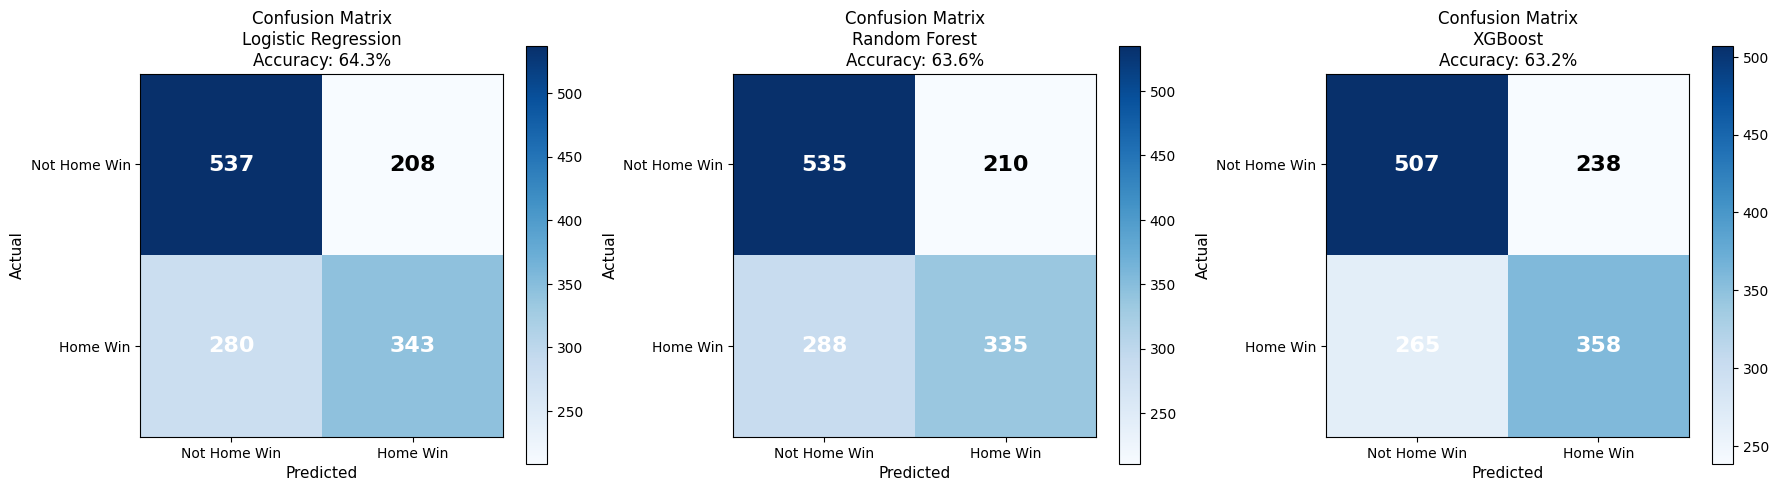

In [9]:
# Plot confusion matrix for each model
fig, axes = plt.subplots(1, len(trained_models), figsize=(6 * len(trained_models), 5))

if len(trained_models) == 1:
    axes = [axes]

labels = ['Not Home Win', 'Home Win']

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    acc    = accuracy_score(y_test, y_pred)
    cm     = confusion_matrix(y_test, y_pred)

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'Confusion Matrix\n{name}\nAccuracy: {acc*100:.1f}%', fontsize=12)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black',
                    fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


## Confusion Matrix Analysis

- Logistic Regression achieved the highest accuracy (64.3%) among the three models.
- Random Forest and XGBoost produced similar performance, with accuracy around 63%.
- All models predicted the **Not Home Win** class better than the **Home Win** class.
- The number of false negatives and false positives is still relatively high, indicating that predicting football match outcomes remains challenging.
- Overall, Logistic Regression was selected as the best baseline model due to its slightly better performance and more balanced predictions.

## 9. ROC Curve — All Models

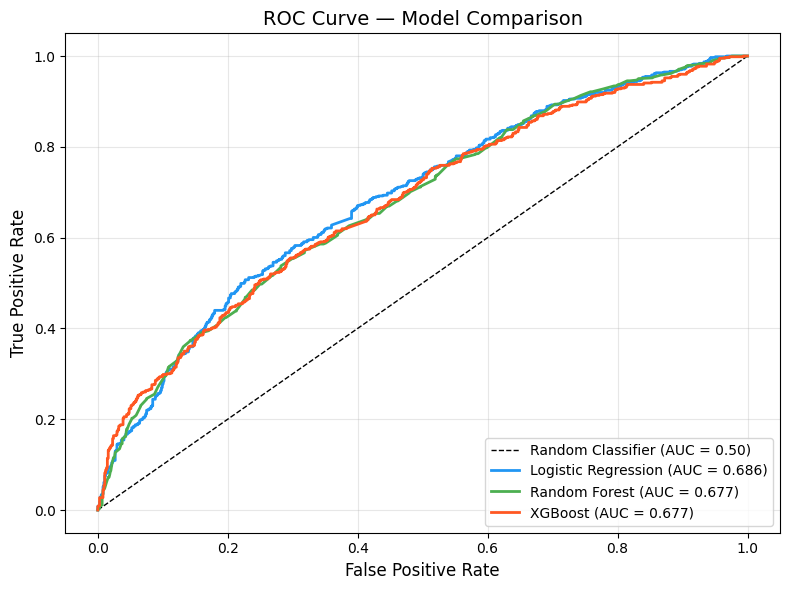

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot diagonal baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')

colors = ['#2196F3', '#4CAF50', '#FF5722']

for (name, model), color in zip(trained_models.items(), colors):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    auc   = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## ROC Curve Analysis

- All models performed better than a random classifier (AUC > 0.50).
- The ROC curves are relatively close to each other, indicating similar classification performance.
- Logistic Regression achieved the best overall balance between True Positive Rate and False Positive Rate.
- Random Forest and XGBoost showed competitive performance but did not significantly outperform Logistic Regression.
- Overall, the models have moderate predictive power, suggesting that football match outcomes are difficult to predict perfectly due to the uncertainty of sports data.

## 10. Feature Importance — Best Model

Best model by ROC-AUC: Logistic Regression


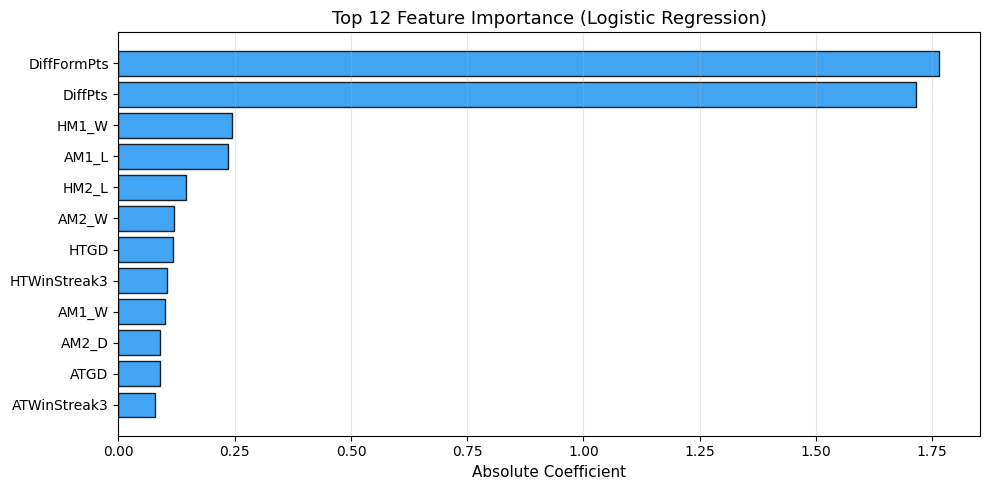

In [11]:
# Select the model with the highest ROC-AUC for feature importance analysis
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = trained_models[best_model_name]

print(f"Best model by ROC-AUC: {best_model_name}")

# Extract feature importances
if hasattr(best_model, 'feature_importances_'):
    # Tree-based models (Random Forest, XGBoost)
    importances = best_model.feature_importances_
    importance_label = 'Feature Importance Score'
elif hasattr(best_model, 'coef_'):
    # Linear models (Logistic Regression)
    importances = np.abs(best_model.coef_[0])
    importance_label = 'Absolute Coefficient'
else:
    importances = None

if importances is not None:
    imp_df = (pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
              .sort_values('Importance', ascending=False)
              .head(12))

    colors = ['#2196F3'] * len(imp_df)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
            color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'Top 12 Feature Importance ({best_model_name})', fontsize=13)
    ax.set_xlabel(importance_label, fontsize=11)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


`DiffPts` and `DiffFormPts` were the most important variables.

This suggests that:
- stronger teams are more likely to win
- recent form has a significant impact on match outcomes

Goal difference (`HTGD`, `ATGD`) also reflects both attacking and defensive quality.

## 11. Classification Report — Detailed Breakdown

In [12]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=['Not Home Win (0)', 'Home Win (1)']))


  Logistic Regression
                  precision    recall  f1-score   support

Not Home Win (0)       0.66      0.72      0.69       745
    Home Win (1)       0.62      0.55      0.58       623

        accuracy                           0.64      1368
       macro avg       0.64      0.64      0.64      1368
    weighted avg       0.64      0.64      0.64      1368

  Random Forest
                  precision    recall  f1-score   support

Not Home Win (0)       0.65      0.72      0.68       745
    Home Win (1)       0.61      0.54      0.57       623

        accuracy                           0.64      1368
       macro avg       0.63      0.63      0.63      1368
    weighted avg       0.63      0.64      0.63      1368

  XGBoost
                  precision    recall  f1-score   support

Not Home Win (0)       0.66      0.68      0.67       745
    Home Win (1)       0.60      0.57      0.59       623

        accuracy                           0.63      1368
       macro avg

## 12. Sample Prediction Demo

In [13]:
# Demonstrate a single prediction using the best model
sample_idx   = 0
sample       = X_test.iloc[[sample_idx]]
sample_scaled = scaler.transform(sample)

pred_label = best_model.predict(sample_scaled)[0]
pred_proba = best_model.predict_proba(sample_scaled)[0]
actual     = y_test.iloc[sample_idx]

print("=== SAMPLE PREDICTION DEMO ===")
print(f"Model used   : {best_model_name}")
print(f"Prediction   : {'Home Win' if pred_label == 1 else 'Not Home Win'} "
      f"(Confidence: {pred_proba[pred_label]*100:.1f}%)")
print(f"Actual result: {'Home Win' if actual == 1 else 'Not Home Win'}")
print(f"Outcome      : {'Correct' if pred_label == actual else 'Incorrect'}")


=== SAMPLE PREDICTION DEMO ===
Model used   : Logistic Regression
Prediction   : Home Win (Confidence: 68.7%)
Actual result: Home Win
Outcome      : Correct



## MODEL VALIDATION CHECKLIST

| # | Item | Detail |
|---|---|---|
| 1 | **Validation Strategy** | Temporal Split — 80% train (2000–2014), 20% test (2014–2018) |
| 2 | **Data Leakage Prevention** | Scaler fitted on train set only; transform applied separately to test set |
| 3 | **Leakage-Free Features** | Match result columns (`FTHG`, `FTAG`) and redundant aggregates excluded |
| 4 | **Evaluation Metrics** | Accuracy, Precision, Recall, F1-Score, ROC-AUC |
| 5 | **Baseline Comparison** | Majority-class baseline established; all models measured against it |
| 6 | **Multiple Models** | Logistic Regression (baseline model), Random Forest, XGBoost |

**Current Limitations:**

- Past statistics may not reflect team strength after major player transfers or coaching changes.
- Injuries, red cards, and referee decisions are not captured in the feature set.
- Match importance (e.g., title run-in, relegation battles) is not encoded.
- Model trained on EPL data only — generalisation to other leagues is not guaranteed.


## Conclusion

The models successfully predicted EPL match outcomes using historical team statistics.

Recent form and overall team strength were the strongest predictors.

Although machine learning improved prediction accuracy, football results still contain randomness and unpredictable factors.